# Thực nghiệm: Feature Selection trong mô hình hồi quy tuyến tính

Mục tiêu của thực nghiệm này là so sánh một số phương pháp lựa chọn biến trong hồi quy tuyến tính, bao gồm:

- Mô hình hồi quy đầy đủ;
- Best subset selection theo $R^2_{\text{adj}}$;
- Best subset selection theo AIC;
- Best subset selection theo BIC;
- Forward selection;
- Backward elimination;
- LASSO.

Các mô hình được xây dựng trên tập huấn luyện và được đánh giá trên tập kiểm tra bằng RMSE, MAE và $R^2_{\text{test}}$.


# Import and loading libraries


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import statsmodels.api as sm

from itertools import combinations
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  
Number of observations: 442
Number of features: 10


## 1. Dữ liệu sử dụng

Trong thực nghiệm này, ta sử dụng bộ dữ liệu `diabetes` có sẵn trong thư viện `scikit-learn`. Đây là bộ dữ liệu hồi quy, trong đó biến mục tiêu là một đại lượng liên tục biểu diễn mức độ tiến triển của bệnh sau một năm.

Bộ dữ liệu gồm 442 quan sát và 10 biến dự báo. Các biến dự báo đã được chuẩn hóa sẵn, do đó phù hợp để minh họa các phương pháp lựa chọn biến trong mô hình hồi quy tuyến tính.


In [3]:
# loading dataset
data = load_diabetes(as_frame=True)

X = data.data
y = data.target

features = list(X.columns)

print("Số quan sát:", X.shape[0])
print("Số biến dự báo:", X.shape[1])
print("Danh sách biến:", features)

display(X.head())

Số quan sát: 442
Số biến dự báo: 10
Danh sách biến: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


## 2. Chia dữ liệu thành tập huấn luyện và tập kiểm tra

Dữ liệu được chia thành hai phần:

- Tập huấn luyện: dùng để xây dựng mô hình, chọn biến và ước lượng hệ số hồi quy.
- Tập kiểm tra: chỉ dùng ở bước cuối cùng để đánh giá khả năng dự đoán của mô hình trên dữ liệu mới.

Trong thực nghiệm này, ta sử dụng 70% dữ liệu cho tập huấn luyện và 30% dữ liệu cho tập kiểm tra.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print("Kích thước tập huấn luyện:", X_train.shape)
print("Kích thước tập kiểm tra:", X_test.shape)

Kích thước tập huấn luyện: (309, 10)
Kích thước tập kiểm tra: (133, 10)


In [1]:
def fit_ols(X_data, y_data, selected_features):
    """
    Xây dựng mô hình hồi quy tuyến tính OLS với tập biến được chọn.
    """
    X_const = sm.add_constant(X_data[selected_features], has_constant="add")
    model = sm.OLS(y_data, X_const).fit()
    return model


def evaluate_ols_model(model, selected_features, model_name):
    """
    Đánh giá mô hình OLS trên tập kiểm tra.
    """
    X_test_const = sm.add_constant(X_test[selected_features], has_constant="add")
    y_pred = model.predict(X_test_const)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    test_r2 = r2_score(y_test, y_pred)

    return {
        "Model": model_name,
        "Num_Features": len(selected_features),
        "Features": ", ".join(selected_features),
        "Train_Adj_R2": model.rsquared_adj,
        "Train_AIC": model.aic,
        "Train_BIC": model.bic,
        "Test_RMSE": rmse,
        "Test_MAE": mae,
        "Test_R2": test_r2,
    }

## 3. Mô hình hồi quy đầy đủ

Trước hết, ta xây dựng mô hình hồi quy tuyến tính đầy đủ, tức là mô hình sử dụng toàn bộ các biến dự báo. Mô hình này đóng vai trò là mô hình tham chiếu để so sánh với các mô hình sau khi lựa chọn biến.


In [7]:
results = []

full_model = fit_ols(X_train, y_train, features)

results.append(evaluate_ols_model(full_model, features, "Full OLS"))

print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.524
Model:                            OLS   Adj. R-squared:                  0.508
Method:                 Least Squares   F-statistic:                     32.86
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           1.37e-42
Time:                        13:35:35   Log-Likelihood:                -1671.5
No. Observations:                 309   AIC:                             3365.
Df Residuals:                     298   BIC:                             3406.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        151.0082      3.143     48.050      0.0

## 4. Best subset selection

Với $p$ biến dự báo, phương pháp best subset selection sẽ xét tất cả các tập con biến có thể có. Trong bộ dữ liệu này có 10 biến dự báo, do đó tổng số mô hình khác rỗng cần xét là:

$$
2^{10} - 1 = 1023.
$$

Mỗi mô hình được xây dựng trên tập huấn luyện, sau đó được đánh giá bằng $R^2_{\text{adj}}$, AIC và BIC. Ta chọn:

- Mô hình có $R^2_{\text{adj}}$ lớn nhất;
- Mô hình có AIC nhỏ nhất;
- Mô hình có BIC nhỏ nhất.


In [8]:
def best_subset_selection(criterion="aic"):
    """
    Thực hiện best subset selection.

    criterion:
    - "adj_r2": chọn mô hình có adjusted R-squared lớn nhất
    - "aic": chọn mô hình có AIC nhỏ nhất
    - "bic": chọn mô hình có BIC nhỏ nhất
    """
    subset_results = []

    for k in range(1, len(features) + 1):
        for subset in combinations(features, k):
            subset = list(subset)
            model = fit_ols(X_train, y_train, subset)

            subset_results.append(
                {
                    "features": subset,
                    "num_features": k,
                    "adj_r2": model.rsquared_adj,
                    "aic": model.aic,
                    "bic": model.bic,
                    "model": model,
                }
            )

    df_subsets = pd.DataFrame(subset_results)

    if criterion == "adj_r2":
        best_row = df_subsets.loc[df_subsets["adj_r2"].idxmax()]
    elif criterion == "aic":
        best_row = df_subsets.loc[df_subsets["aic"].idxmin()]
    elif criterion == "bic":
        best_row = df_subsets.loc[df_subsets["bic"].idxmin()]
    else:
        raise ValueError("criterion must be 'adj_r2', 'aic', or 'bic'")

    return best_row["features"], best_row["model"], df_subsets

In [9]:
best_adj_features, best_adj_model, all_subset_results = best_subset_selection("adj_r2")
best_aic_features, best_aic_model, _ = best_subset_selection("aic")
best_bic_features, best_bic_model, _ = best_subset_selection("bic")

results.append(
    evaluate_ols_model(best_adj_model, best_adj_features, "Best Subset - Adj R2")
)

results.append(
    evaluate_ols_model(best_aic_model, best_aic_features, "Best Subset - AIC")
)

results.append(
    evaluate_ols_model(best_bic_model, best_bic_features, "Best Subset - BIC")
)

print("Best subset theo Adjusted R2:", best_adj_features)
print("Best subset theo AIC:", best_aic_features)
print("Best subset theo BIC:", best_bic_features)

Best subset theo Adjusted R2: ['sex', 'bmi', 'bp', 's1', 's2', 's4', 's5']
Best subset theo AIC: ['sex', 'bmi', 'bp', 's1', 's2', 's4', 's5']
Best subset theo BIC: ['sex', 'bmi', 'bp', 's3', 's5']


In [10]:
best_by_size = []

for k in range(1, len(features) + 1):
    temp = all_subset_results[all_subset_results["num_features"] == k]

    best_adj = temp.loc[temp["adj_r2"].idxmax()]
    best_aic = temp.loc[temp["aic"].idxmin()]
    best_bic = temp.loc[temp["bic"].idxmin()]

    best_by_size.append(
        {
            "Num_Features": k,
            "Best_Adj_R2": best_adj["adj_r2"],
            "Adj_R2_Features": ", ".join(best_adj["features"]),
            "Best_AIC": best_aic["aic"],
            "AIC_Features": ", ".join(best_aic["features"]),
            "Best_BIC": best_bic["bic"],
            "BIC_Features": ", ".join(best_bic["features"]),
        }
    )

best_by_size_df = pd.DataFrame(best_by_size)
display(best_by_size_df)

,Num_Features,Best_Adj_R2,Adj_R2_Features,Best_AIC,AIC_Features,Best_BIC,BIC_Features
0,1,0.363699,bmi,3435.898949,bmi,3443.365632,bmi
1,2,0.441356,"bmi, s5",3396.671398,"bmi, s5",3407.871421,"bmi, s5"
2,3,0.469348,"bmi, bp, s5",3381.775600,"bmi, bp, s5",3396.708965,"bmi, bp, s5"
3,4,0.486921,"bmi, bp, s3, s5",3372.354619,"bmi, bp, s3, s5",3391.021325,"bmi, bp, s3, s5"
4,5,0.504843,"sex, bmi, bp, s3, s5",3362.350532,"sex, bmi, bp, s3, s5",3384.750580,"sex, bmi, bp, s3, s5"
5,6,0.510251,"sex, bmi, bp, s1, s4, s5",3359.935178,"sex, bmi, bp, s1, s4, s5",3386.068567,"sex, bmi, bp, s1, s4, s5"
6,7,0.512106,"sex, bmi, bp, s1, s2, s4, s5",3359.738214,"sex, bmi, bp, s1, s2, s4, s5",3389.604944,"sex, bmi, bp, s1, s2, s4, s5"
7,8,0.511034,"sex, bmi, bp, s1, s2, s4, s5, s6",3361.387981,"sex, bmi, bp, s1, s2, s4, s5, s6",3394.988053,"sex, bmi, bp, s1, s2, s4, s5, s6"
8,9,0.509842,"sex, bmi, bp, s1, s2, s3, s4, s5, s6",3363.108421,"sex, bmi, bp, s1, s2, s3, s4, s5, s6",3400.441833,"sex, bmi, bp, s1, s2, s3, s4, s5, s6"
9,10,0.508453,"age, sex, bmi, bp, s1, s2, s3, s4, s5, s6",3364.947631,"age, sex, bmi, bp, s1, s2, s3, s4, s5, s6",3406.014385,"age, sex, bmi, bp, s1, s2, s3, s4, s5, s6"


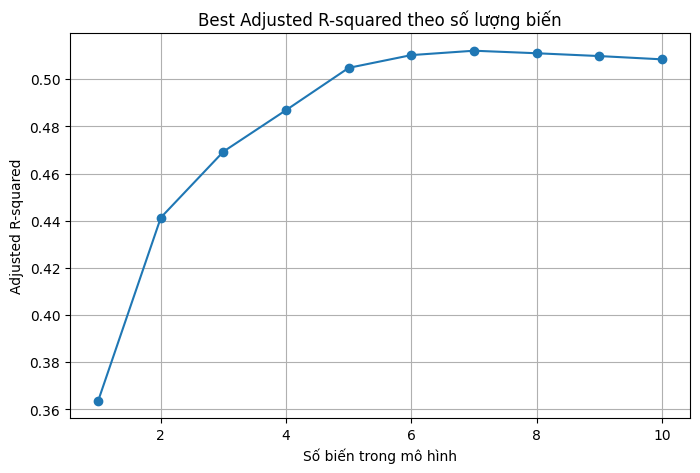

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(best_by_size_df["Num_Features"], best_by_size_df["Best_Adj_R2"], marker="o")
plt.xlabel("Số biến trong mô hình")
plt.ylabel("Adjusted R-squared")
plt.title("Best Adjusted R-squared theo số lượng biến")
plt.grid(True)
plt.show()

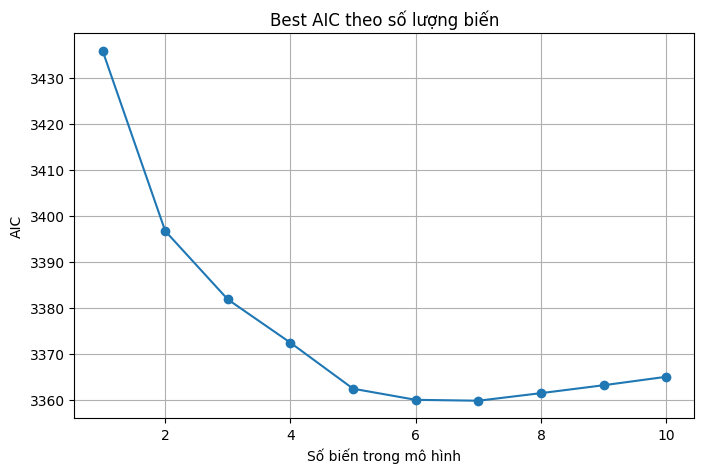

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(best_by_size_df["Num_Features"], best_by_size_df["Best_AIC"], marker="o")
plt.xlabel("Số biến trong mô hình")
plt.ylabel("AIC")
plt.title("Best AIC theo số lượng biến")
plt.grid(True)
plt.show()

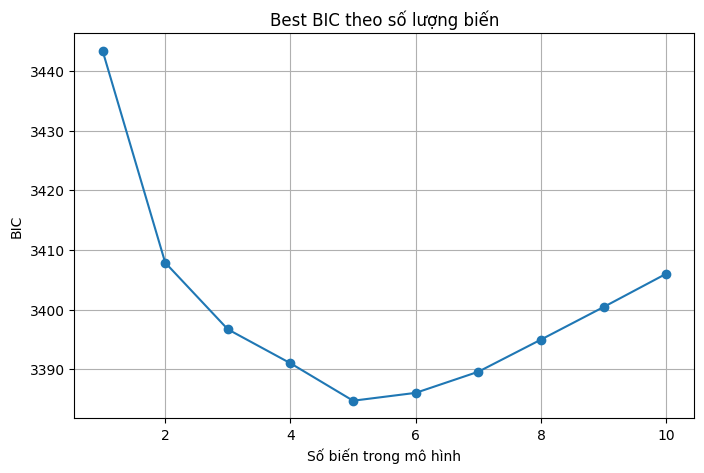

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(best_by_size_df["Num_Features"], best_by_size_df["Best_BIC"], marker="o")
plt.xlabel("Số biến trong mô hình")
plt.ylabel("BIC")
plt.title("Best BIC theo số lượng biến")
plt.grid(True)
plt.show()

## 5. Forward selection

Phương pháp forward selection bắt đầu từ mô hình rỗng. Ở mỗi bước, một biến mới được thêm vào nếu việc thêm biến đó giúp cải thiện tiêu chí lựa chọn mô hình. Trong thực nghiệm này, ta xét forward selection theo AIC và BIC.


In [14]:
def forward_selection(criterion="aic"):
    remaining_features = set(features)
    selected_features = []

    if criterion == "adj_r2":
        best_score = -np.inf
    else:
        best_score = np.inf

    best_model = None

    while len(remaining_features) > 0:
        candidates = []

        for feature in sorted(remaining_features):
            candidate_features = selected_features + [feature]
            model = fit_ols(X_train, y_train, candidate_features)

            if criterion == "adj_r2":
                score = model.rsquared_adj
            elif criterion == "aic":
                score = model.aic
            elif criterion == "bic":
                score = model.bic
            else:
                raise ValueError("criterion must be 'adj_r2', 'aic', or 'bic'")

            candidates.append((score, feature, model))

        if criterion == "adj_r2":
            candidates.sort(reverse=True, key=lambda x: x[0])
            candidate_score, candidate_feature, candidate_model = candidates[0]
            improved = candidate_score > best_score
        else:
            candidates.sort(key=lambda x: x[0])
            candidate_score, candidate_feature, candidate_model = candidates[0]
            improved = candidate_score < best_score

        if improved:
            selected_features.append(candidate_feature)
            remaining_features.remove(candidate_feature)
            best_score = candidate_score
            best_model = candidate_model
        else:
            break

    return selected_features, best_model

In [15]:
forward_aic_features, forward_aic_model = forward_selection("aic")
forward_bic_features, forward_bic_model = forward_selection("bic")

results.append(
    evaluate_ols_model(
        forward_aic_model, forward_aic_features, "Forward Selection - AIC"
    )
)

results.append(
    evaluate_ols_model(
        forward_bic_model, forward_bic_features, "Forward Selection - BIC"
    )
)

print("Forward selection theo AIC:", forward_aic_features)
print("Forward selection theo BIC:", forward_bic_features)

Forward selection theo AIC: ['bmi', 's5', 'bp', 's3', 'sex', 's1']
Forward selection theo BIC: ['bmi', 's5', 'bp', 's3', 'sex']


## 6. Backward elimination

Phương pháp backward elimination bắt đầu từ mô hình đầy đủ. Ở mỗi bước, một biến được loại bỏ nếu việc loại bỏ biến đó giúp cải thiện tiêu chí lựa chọn mô hình. Trong thực nghiệm này, ta xét backward elimination theo AIC và BIC.


In [16]:
def backward_elimination(criterion="aic"):
    selected_features = features.copy()
    current_model = fit_ols(X_train, y_train, selected_features)

    if criterion == "adj_r2":
        current_score = current_model.rsquared_adj
    elif criterion == "aic":
        current_score = current_model.aic
    elif criterion == "bic":
        current_score = current_model.bic
    else:
        raise ValueError("criterion must be 'adj_r2', 'aic', or 'bic'")

    best_model = current_model

    while len(selected_features) > 1:
        candidates = []

        for feature in selected_features:
            candidate_features = [f for f in selected_features if f != feature]
            model = fit_ols(X_train, y_train, candidate_features)

            if criterion == "adj_r2":
                score = model.rsquared_adj
            elif criterion == "aic":
                score = model.aic
            elif criterion == "bic":
                score = model.bic

            candidates.append((score, feature, candidate_features, model))

        if criterion == "adj_r2":
            candidates.sort(reverse=True, key=lambda x: x[0])
            candidate_score, removed_feature, candidate_features, candidate_model = (
                candidates[0]
            )
            improved = candidate_score > current_score
        else:
            candidates.sort(key=lambda x: x[0])
            candidate_score, removed_feature, candidate_features, candidate_model = (
                candidates[0]
            )
            improved = candidate_score < current_score

        if improved:
            selected_features = candidate_features
            current_score = candidate_score
            best_model = candidate_model
        else:
            break

    return selected_features, best_model

In [17]:
backward_aic_features, backward_aic_model = backward_elimination("aic")
backward_bic_features, backward_bic_model = backward_elimination("bic")

results.append(
    evaluate_ols_model(
        backward_aic_model, backward_aic_features, "Backward Elimination - AIC"
    )
)

results.append(
    evaluate_ols_model(
        backward_bic_model, backward_bic_features, "Backward Elimination - BIC"
    )
)

print("Backward elimination theo AIC:", backward_aic_features)
print("Backward elimination theo BIC:", backward_bic_features)

Backward elimination theo AIC: ['sex', 'bmi', 'bp', 's1', 's2', 's4', 's5']
Backward elimination theo BIC: ['sex', 'bmi', 'bp', 's1', 's4', 's5']


## 7. LASSO

LASSO là một phương pháp lựa chọn biến thuộc nhóm embedded methods. Phương pháp này thêm phần phạt $L_1$ vào hàm mất mát, nhờ đó có thể đưa một số hệ số hồi quy về đúng 0. Các biến có hệ số bằng 0 được xem là bị loại khỏi mô hình.

Trước khi áp dụng LASSO, các biến dự báo cần được chuẩn hóa vì phần phạt của LASSO phụ thuộc trực tiếp vào độ lớn của các hệ số hồi quy.


In [18]:
lasso_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("lasso", LassoCV(cv=10, random_state=42, max_iter=10000)),
    ]
)

lasso_pipeline.fit(X_train, y_train)

lasso_model = lasso_pipeline.named_steps["lasso"]
lasso_coef = pd.Series(lasso_model.coef_, index=features)

lasso_selected_features = list(lasso_coef[lasso_coef.abs() > 1e-6].index)

print("Giá trị alpha tốt nhất của LASSO:", lasso_model.alpha_)
print("\nHệ số LASSO:")
display(lasso_coef.to_frame(name="Coefficient"))

print("\nCác biến được LASSO giữ lại:")
print(lasso_selected_features)

Giá trị alpha tốt nhất của LASSO: 0.10955050687279642

Hệ số LASSO:


,Coefficient
age,1.355776
sex,-12.189759
bmi,26.469847
bp,18.398644
s1,-30.260018
s2,14.274916
s3,-0.000000
s4,11.833763
s5,26.661138
s6,2.061890



Các biến được LASSO giữ lại:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's4', 's5', 's6']


In [19]:
y_pred_lasso = lasso_pipeline.predict(X_test)

lasso_result = {
    "Model": "LASSO-CV",
    "Num_Features": len(lasso_selected_features),
    "Features": ", ".join(lasso_selected_features),
    "Train_Adj_R2": np.nan,
    "Train_AIC": np.nan,
    "Train_BIC": np.nan,
    "Test_RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
    "Test_MAE": mean_absolute_error(y_test, y_pred_lasso),
    "Test_R2": r2_score(y_test, y_pred_lasso),
}

results.append(lasso_result)

print("LASSO Test RMSE:", lasso_result["Test_RMSE"])
print("LASSO Test MAE:", lasso_result["Test_MAE"])
print("LASSO Test R2:", lasso_result["Test_R2"])

LASSO Test RMSE: 53.07189305908942
LASSO Test MAE: 41.86188729367976
LASSO Test R2: 0.4782391154572808


In [20]:
if len(lasso_selected_features) > 0:
    lasso_refit_model = fit_ols(X_train, y_train, lasso_selected_features)

    results.append(
        evaluate_ols_model(
            lasso_refit_model, lasso_selected_features, "OLS Refit after LASSO"
        )
    )

    print(lasso_refit_model.summary())
else:
    print("LASSO không giữ lại biến nào.")

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.524
Model:                            OLS   Adj. R-squared:                  0.510
Method:                 Least Squares   F-statistic:                     36.58
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           2.48e-43
Time:                        13:43:08   Log-Likelihood:                -1671.6
No. Observations:                 309   AIC:                             3363.
Df Residuals:                     299   BIC:                             3401.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        151.0002      3.139     48.109      0.0

## 8. So sánh các mô hình trên tập kiểm tra

Sau khi xây dựng các mô hình trên tập huấn luyện, ta so sánh hiệu suất dự đoán của chúng trên tập kiểm tra. Các tiêu chí được sử dụng bao gồm:

$
RMSE =
\sqrt{
\frac{1}{n_{\text{test}}}
\sum_{i=1}^{n_{\text{test}}}
(y_i - \hat{y}_i)^2
}
$

$
MAE =
\frac{1}{n_{\text{test}}}
\sum_{i=1}^{n_{\text{test}}}
|y_i - \hat{y}_i|
$

và $R^2_{\text{test}}$.

Trong đó, RMSE và MAE càng nhỏ thì mô hình dự đoán càng tốt, còn $R^2_{\text{test}}$ càng lớn thì mô hình giải thích tốt hơn sự biến thiên của biến mục tiêu trên tập kiểm tra.


In [21]:
results_df = pd.DataFrame(results)

# Sắp xếp theo RMSE trên tập kiểm tra
results_df = results_df.sort_values("Test_RMSE").reset_index(drop=True)

display(results_df)

,Model,Num_Features,Features,Train_Adj_R2,Train_AIC,Train_BIC,Test_RMSE,Test_MAE,Test_R2
0,Forward Selection - AIC,6,"bmi, s5, bp, s3, sex, s1",0.508215,3361.217311,3387.350700,52.898720,41.985112,0.481639
1,LASSO-CV,9,"age, sex, bmi, bp, s1, s2, s4, s5, s6",NaN,NaN,NaN,53.071893,41.861887,0.478239
2,Forward Selection - BIC,5,"bmi, s5, bp, s3, sex",0.504843,3362.350532,3384.750580,53.098791,42.396818,0.477710
3,Best Subset - BIC,5,"sex, bmi, bp, s3, s5",0.504843,3362.350532,3384.750580,53.098791,42.396818,0.477710
4,Backward Elimination - AIC,7,"sex, bmi, bp, s1, s2, s4, s5",0.512106,3359.738214,3389.604944,53.120084,41.898903,0.477291
5,Best Subset - AIC,7,"sex, bmi, bp, s1, s2, s4, s5",0.512106,3359.738214,3389.604944,53.120084,41.898903,0.477291
6,Best Subset - Adj R2,7,"sex, bmi, bp, s1, s2, s4, s5",0.512106,3359.738214,3389.604944,53.120084,41.898903,0.477291
7,Full OLS,10,"age, sex, bmi, bp, s1, s2, s3, s4, s5, s6",0.508453,3364.947631,3406.014385,53.120156,41.919378,0.477290
8,OLS Refit after LASSO,9,"age, sex, bmi, bp, s1, s2, s4, s5, s6",0.509697,3363.199833,3400.533246,53.128346,41.908912,0.477129
9,Backward Elimination - BIC,6,"sex, bmi, bp, s1, s4, s5",0.510251,3359.935178,3386.068567,53.265516,41.979433,0.474425


In [22]:
report_table = results_df.copy()

numeric_cols = [
    "Train_Adj_R2",
    "Train_AIC",
    "Train_BIC",
    "Test_RMSE",
    "Test_MAE",
    "Test_R2",
]

for col in numeric_cols:
    report_table[col] = report_table[col].round(4)

display(report_table)

,Model,Num_Features,Features,Train_Adj_R2,Train_AIC,Train_BIC,Test_RMSE,Test_MAE,Test_R2
0,Forward Selection - AIC,6,"bmi, s5, bp, s3, sex, s1",0.5082,3361.2173,3387.3507,52.8987,41.9851,0.4816
1,LASSO-CV,9,"age, sex, bmi, bp, s1, s2, s4, s5, s6",NaN,NaN,NaN,53.0719,41.8619,0.4782
2,Forward Selection - BIC,5,"bmi, s5, bp, s3, sex",0.5048,3362.3505,3384.7506,53.0988,42.3968,0.4777
3,Best Subset - BIC,5,"sex, bmi, bp, s3, s5",0.5048,3362.3505,3384.7506,53.0988,42.3968,0.4777
4,Backward Elimination - AIC,7,"sex, bmi, bp, s1, s2, s4, s5",0.5121,3359.7382,3389.6049,53.1201,41.8989,0.4773
5,Best Subset - AIC,7,"sex, bmi, bp, s1, s2, s4, s5",0.5121,3359.7382,3389.6049,53.1201,41.8989,0.4773
6,Best Subset - Adj R2,7,"sex, bmi, bp, s1, s2, s4, s5",0.5121,3359.7382,3389.6049,53.1201,41.8989,0.4773
7,Full OLS,10,"age, sex, bmi, bp, s1, s2, s3, s4, s5, s6",0.5085,3364.9476,3406.0144,53.1202,41.9194,0.4773
8,OLS Refit after LASSO,9,"age, sex, bmi, bp, s1, s2, s4, s5, s6",0.5097,3363.1998,3400.5332,53.1283,41.9089,0.4771
9,Backward Elimination - BIC,6,"sex, bmi, bp, s1, s4, s5",0.5103,3359.9352,3386.0686,53.2655,41.9794,0.4744


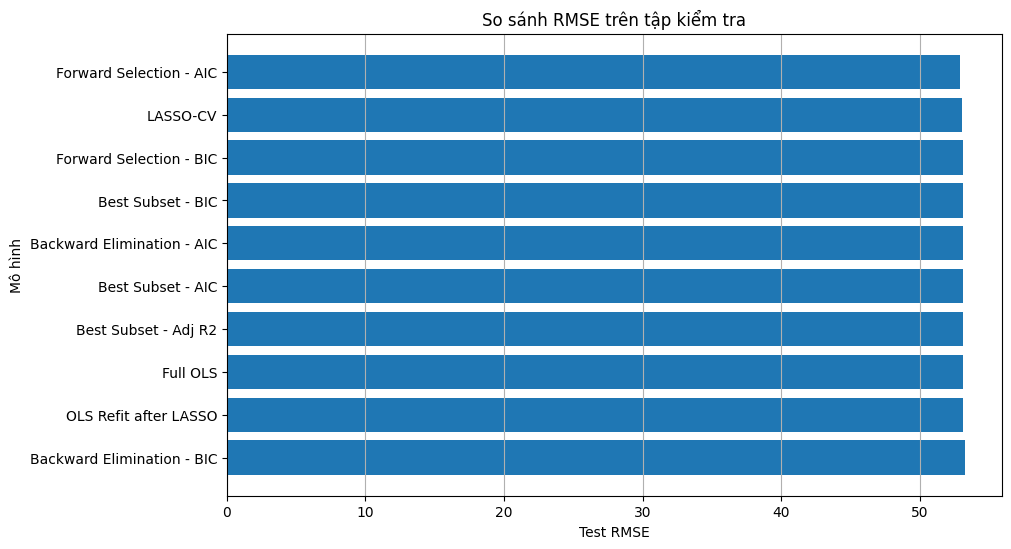

In [23]:
plt.figure(figsize=(10, 6))
plt.barh(results_df["Model"], results_df["Test_RMSE"])
plt.xlabel("Test RMSE")
plt.ylabel("Mô hình")
plt.title("So sánh RMSE trên tập kiểm tra")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

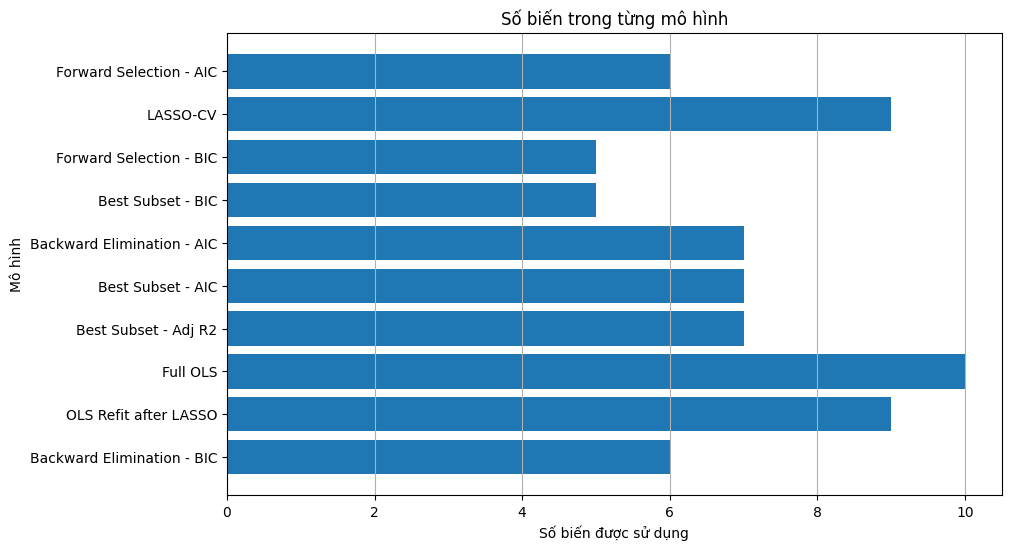

In [24]:
plt.figure(figsize=(10, 6))
plt.barh(results_df["Model"], results_df["Num_Features"])
plt.xlabel("Số biến được sử dụng")
plt.ylabel("Mô hình")
plt.title("Số biến trong từng mô hình")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

## 9. Nhận xét kết quả thực nghiệm

Từ bảng kết quả, ta có thể so sánh các mô hình theo hai khía cạnh chính: khả năng dự đoán trên tập kiểm tra và độ phức tạp của mô hình.

Trước hết, mô hình đầy đủ sử dụng toàn bộ các biến dự báo. Mặc dù mô hình này tận dụng toàn bộ thông tin có trong dữ liệu, nhưng nó không nhất thiết là mô hình có khả năng dự đoán tốt nhất trên tập kiểm tra. Điều này cho thấy việc thêm nhiều biến vào mô hình có thể cải thiện độ khớp trên tập huấn luyện, nhưng không đảm bảo cải thiện khả năng tổng quát hóa trên dữ liệu mới.

Các mô hình được chọn bởi AIC và BIC cho thấy sự khác biệt trong cách xử lý độ phức tạp của mô hình. AIC thường có xu hướng chọn mô hình nhiều biến hơn do mức phạt cho số lượng tham số tương đối nhẹ. Ngược lại, BIC thường chọn mô hình đơn giản hơn vì tiêu chí này phạt mạnh hơn đối với độ phức tạp. Do đó, nếu mục tiêu chính là dự đoán, mô hình theo AIC có thể là một lựa chọn phù hợp. Nếu mục tiêu là xây dựng một mô hình gọn và dễ diễn giải, mô hình theo BIC thường đáng được ưu tiên hơn.

Đối với các phương pháp lựa chọn từng bước, forward selection và backward elimination giúp giảm đáng kể số lượng mô hình cần xét so với best subset selection. Tuy nhiên, do hai phương pháp này bắt đầu từ hai điểm khác nhau, chúng có thể dẫn đến các mô hình cuối cùng khác nhau. Kết quả thực nghiệm cho thấy các phương pháp từng bước có thể tìm được mô hình tương đối tốt với chi phí tính toán thấp hơn.

LASSO là một phương pháp đáng chú ý vì nó thực hiện đồng thời ước lượng hệ số hồi quy và lựa chọn biến. Những biến có hệ số bị đưa về 0 được xem là bị loại khỏi mô hình. Nếu LASSO đạt RMSE hoặc MAE gần tương đương với các mô hình khác nhưng sử dụng ít biến hơn, điều này cho thấy LASSO có khả năng tạo ra mô hình gọn, dễ diễn giải và vẫn giữ được hiệu quả dự đoán tốt.

Nhìn chung, kết quả thực nghiệm minh họa rằng mô hình tốt không nhất thiết là mô hình sử dụng nhiều biến nhất. Một mô hình phù hợp cần đạt được sự cân bằng giữa sai số dự đoán thấp, số lượng biến hợp lý và khả năng diễn giải. Vì vậy, trong thực hành, việc lựa chọn mô hình cuối cùng nên dựa trên nhiều tiêu chí, bao gồm RMSE, MAE, $R^2_{\text{test}}$, số biến được giữ lại và mục tiêu cụ thể của bài toán.
